In [1]:
import pandas as pd

df = pd.read_csv("cleaned_kids_screentime.csv")

In [2]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,activity_type,health_issue_present,device_type,Duration_Category,Usage_Dominance,recreation_intensity,education_intensity,weekday_flag
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Early Teen,Recreational Usage,Health Issue,portable,Moderate (2-4 hrs),Recreation Dominant,Highly Recreational,Normal,weekday
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Pre-Teen,Recreational Usage,Health Issue,portable,High (4-6 hrs),Recreation Dominant,Highly Recreational,Normal,weekend
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Late Teen,Recreational Usage,Health Issue,wall-mounted,Moderate (2-4 hrs),Recreation Dominant,Highly Recreational,Normal,weekday
3,15,Female,1.21,Laptop,False,0.39,No Health Impact,Urban,Late Teen,Recreational Usage,No Health Issue,portable,Low (0-2 hrs),Recreation Dominant,Highly Recreational,Normal,weekday
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Early Teen,Recreational Usage,Health Issue,portable,High (4-6 hrs),Recreation Dominant,Highly Recreational,Normal,weekend


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

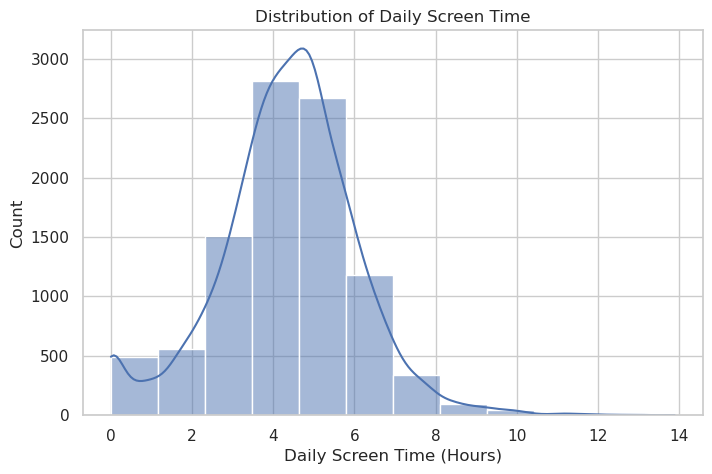

Observation example: Most children fall between 4-6 hours of screen time, while a smaller group exceeds 5+ hours, indicating potential heavy usage cohorts.


In [4]:
# Histogram showing the distribution of average daily screen time among kids
plt.figure(figsize=(8,5))
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=12, kde=True)

plt.title("Distribution of Daily Screen Time")
plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Count")

plt.show()

print("Observation example: Most children fall between 4-6 hours of screen time, while a smaller group exceeds 5+ hours, indicating potential heavy usage cohorts.")

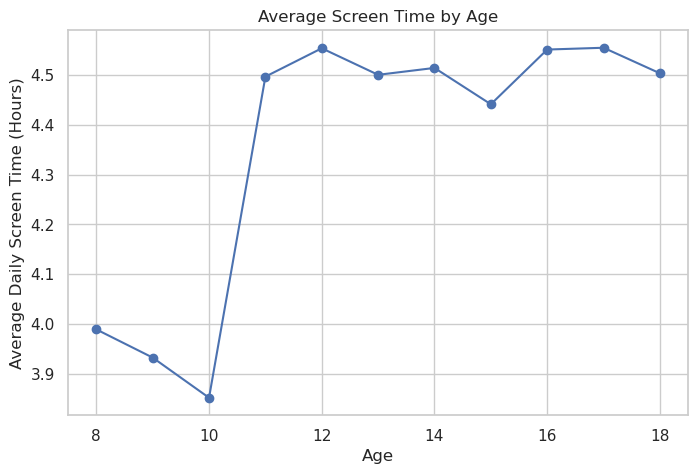

In [5]:
# Line plot showing how average screen time changes with age
age_trend = df.groupby("Age")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure(figsize=(8,5))
age_trend.plot(marker='o')

plt.title("Average Screen Time by Age")
plt.xlabel("Age")
plt.ylabel("Average Daily Screen Time (Hours)")

plt.show()

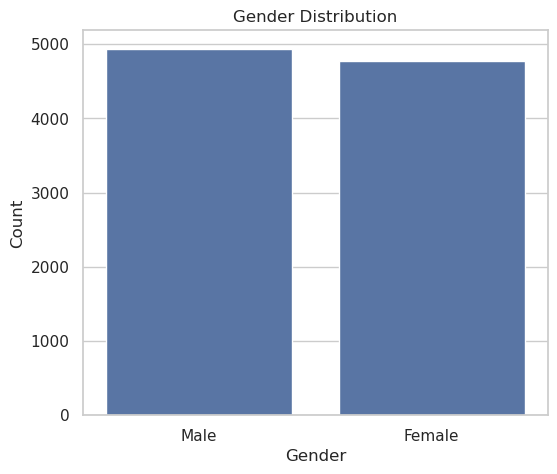

In [6]:
# Bar chart showing number of kids by gender
plt.figure(figsize=(6,5))
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

In [7]:
df["Age_Band"] = pd.cut(
    df["Age"],
    bins=[4, 8, 11, 14, 18],
    labels=["Early Childhood", "Pre-Teen", "Early Teen", "Late Teen"]
)

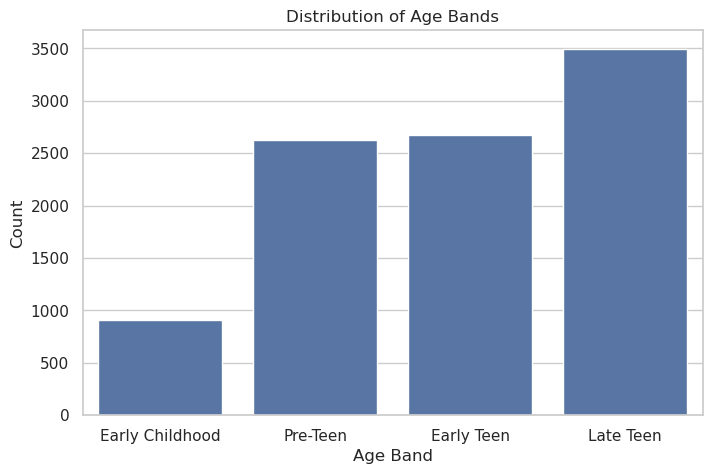

In [8]:
# Bar chart showing distribution of kids across age bands
plt.figure(figsize=(8,5))

sns.countplot(x='Age_Band', data=df)

plt.title("Distribution of Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Count")

plt.show()

<Figure size 800x500 with 0 Axes>

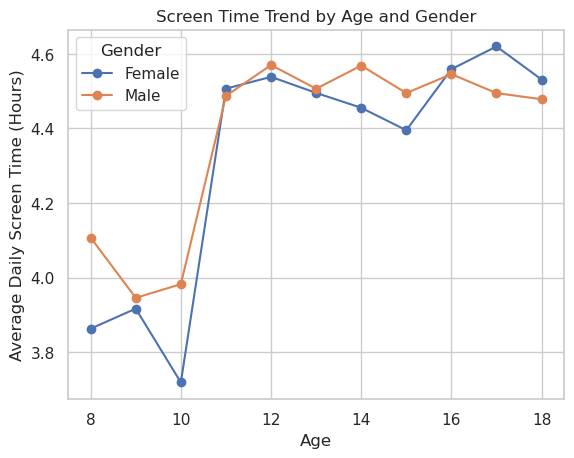

In [9]:
# Line plot comparing screen time trends of males and females across ages
gender_age = df.groupby(["Age","Gender"])["Avg_Daily_Screen_Time_hr"].mean().unstack()

plt.figure(figsize=(8,5))
gender_age.plot(marker='o')

plt.title("Screen Time Trend by Age and Gender")
plt.xlabel("Age")
plt.ylabel("Average Daily Screen Time (Hours)")

plt.show()

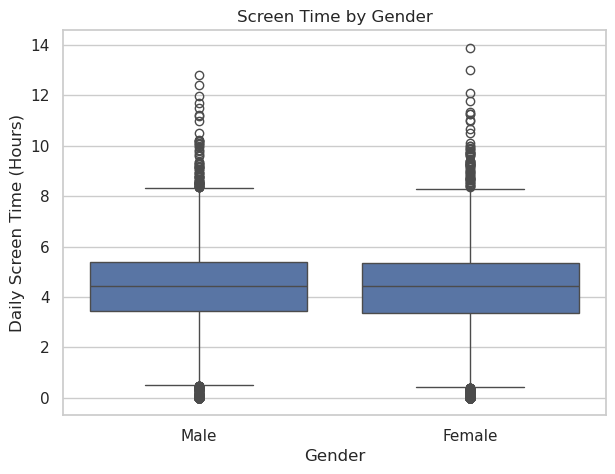

In [10]:
# Boxplot comparing daily screen time between boys and girls
plt.figure(figsize=(7,5))
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)

plt.title("Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Daily Screen Time (Hours)")

plt.show()

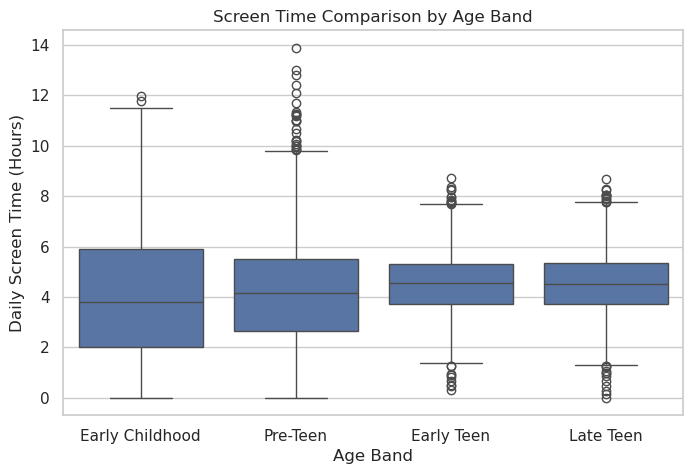

In [11]:
# Boxplot comparing daily screen time across different age bands
plt.figure(figsize=(8,5))

sns.boxplot(x='Age_Band', y='Avg_Daily_Screen_Time_hr', data=df)

plt.title("Screen Time Comparison by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Daily Screen Time (Hours)")

plt.show()

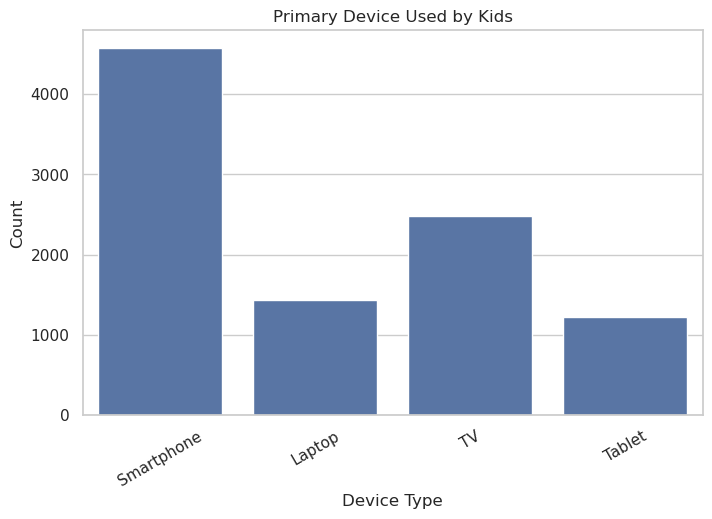

In [12]:
# Bar chart showing which device kids use the most
plt.figure(figsize=(8,5))
sns.countplot(x='Primary_Device', data=df)

plt.title("Primary Device Used by Kids")
plt.xlabel("Device Type")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.show()

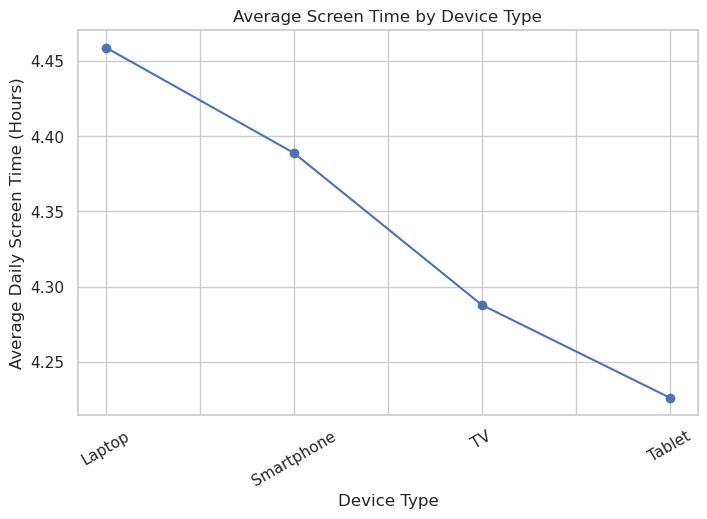

In [13]:
# Line plot showing average screen time for each primary device type
device_usage = df.groupby("Primary_Device")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure(figsize=(8,5))
device_usage.plot(marker='o')

plt.title("Average Screen Time by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Average Daily Screen Time (Hours)")

plt.xticks(rotation=30)

plt.show()

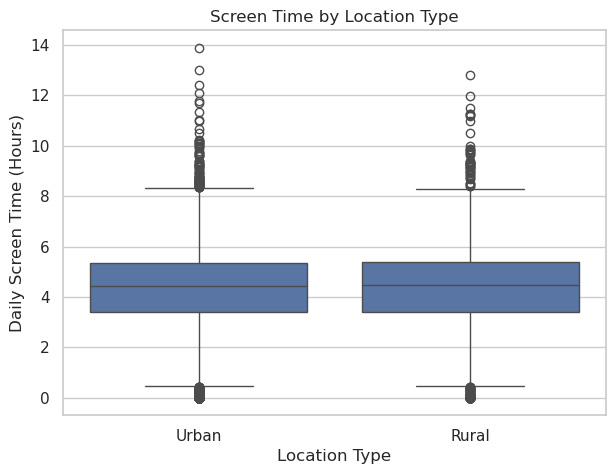

In [14]:
# Boxplot comparing screen time between urban and rural kids
plt.figure(figsize=(7,5))
sns.boxplot(x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', data=df)

plt.title("Screen Time by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Daily Screen Time (Hours)")

plt.show()

<Figure size 800x500 with 0 Axes>

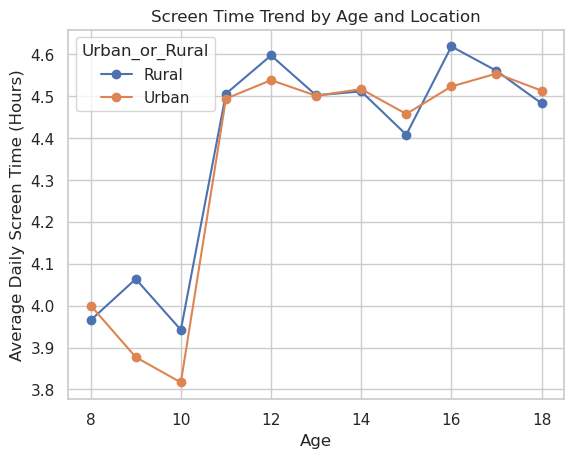

In [15]:
# Line plot showing screen time trend across ages for urban vs rural kids
location_age = df.groupby(["Age","Urban_or_Rural"])["Avg_Daily_Screen_Time_hr"].mean().unstack()

plt.figure(figsize=(8,5))
location_age.plot(marker='o')

plt.title("Screen Time Trend by Age and Location")
plt.xlabel("Age")
plt.ylabel("Average Daily Screen Time (Hours)")

plt.show()

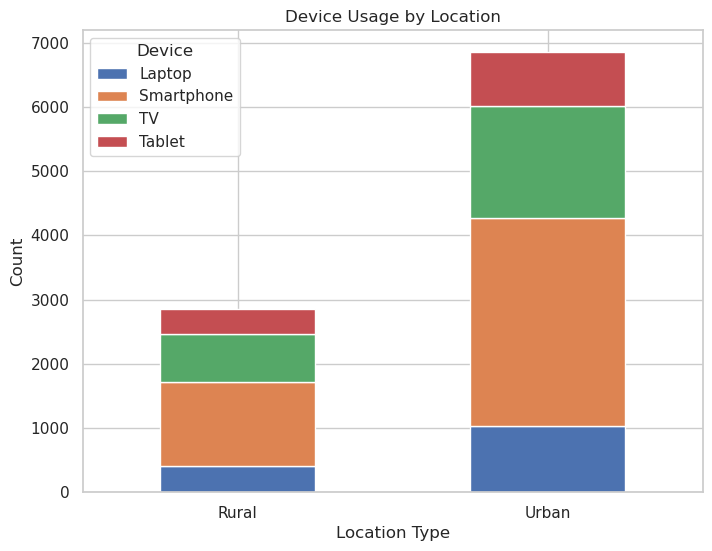

In [16]:
# Stacked bar chart showing device usage differences between urban and rural kids
pd.crosstab(df['Urban_or_Rural'], df['Primary_Device']).plot(
    kind='bar',
    stacked=True,
    figsize=(8,6)
)

plt.title("Device Usage by Location")
plt.xlabel("Location Type")
plt.ylabel("Count")

plt.legend(title="Device")
plt.xticks(rotation=0)

plt.show()

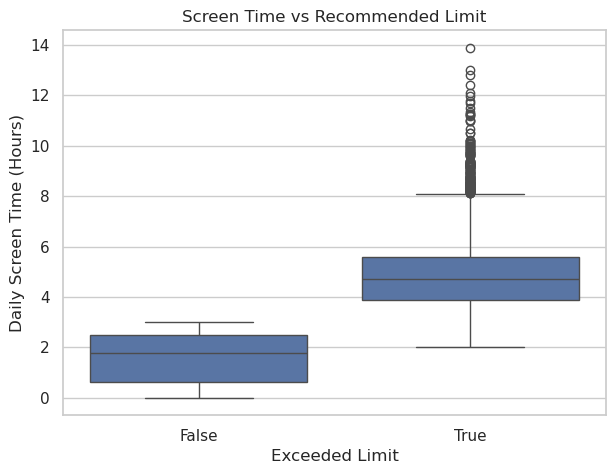

In [17]:
# Boxplot showing screen time distribution for kids who exceeded recommended limit
plt.figure(figsize=(7,5))
sns.boxplot(x='Exceeded_Recommended_Limit', y='Avg_Daily_Screen_Time_hr', data=df)

plt.title("Screen Time vs Recommended Limit")
plt.xlabel("Exceeded Limit")
plt.ylabel("Daily Screen Time (Hours)")

plt.show()

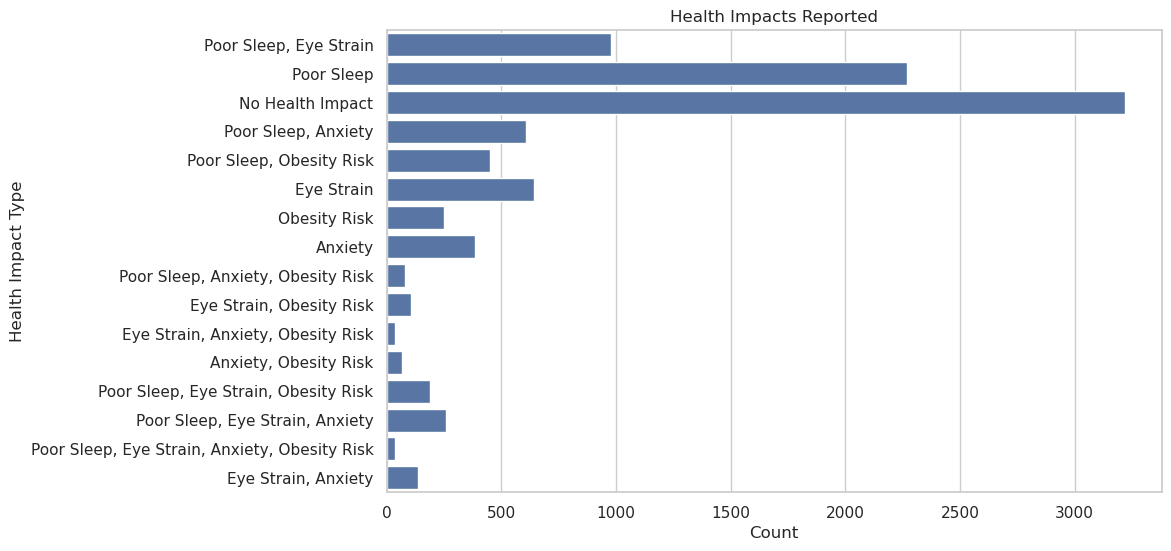

In [18]:
# Horizontal bar chart showing frequency of reported health impacts
plt.figure(figsize=(10,6))

sns.countplot(y='Health_Impacts', data=df)

plt.title("Health Impacts Reported")
plt.xlabel("Count")
plt.ylabel("Health Impact Type")

plt.show()

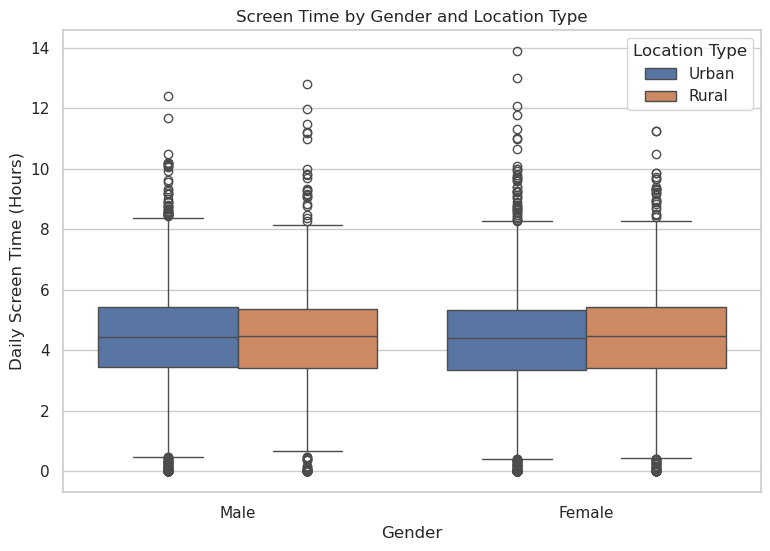

In [19]:
# Boxplot comparing screen time by gender across urban and rural locations
plt.figure(figsize=(9,6))

sns.boxplot(
    x='Gender',
    y='Avg_Daily_Screen_Time_hr',
    hue='Urban_or_Rural',
    data=df
)

plt.title("Screen Time by Gender and Location Type")
plt.xlabel("Gender")
plt.ylabel("Daily Screen Time (Hours)")

plt.legend(title="Location Type")

plt.show()

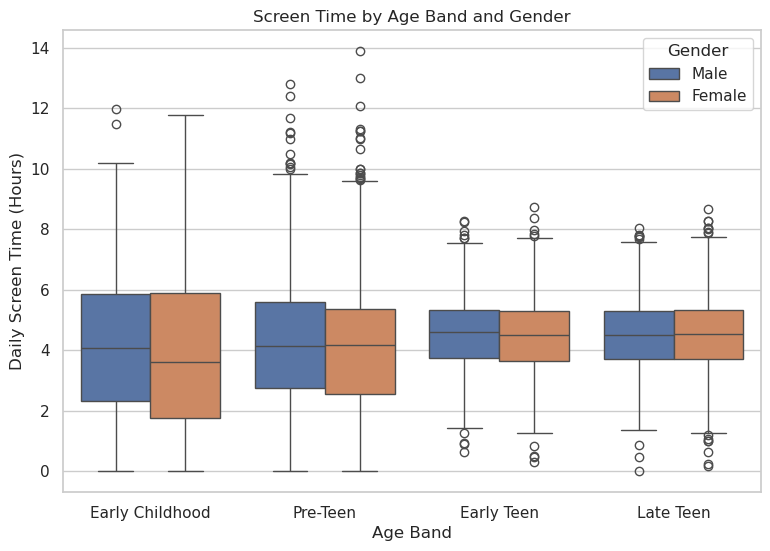

In [20]:
# Boxplot comparing screen time across age bands separated by gender
plt.figure(figsize=(9,6))

sns.boxplot(
    x='Age_Band',
    y='Avg_Daily_Screen_Time_hr',
    hue='Gender',
    data=df
)

plt.title("Screen Time by Age Band and Gender")
plt.xlabel("Age Band")
plt.ylabel("Daily Screen Time (Hours)")

plt.legend(title="Gender")

plt.show()

In [21]:

# Week 4: Device/Activity and Weekday/Weekend Analysis


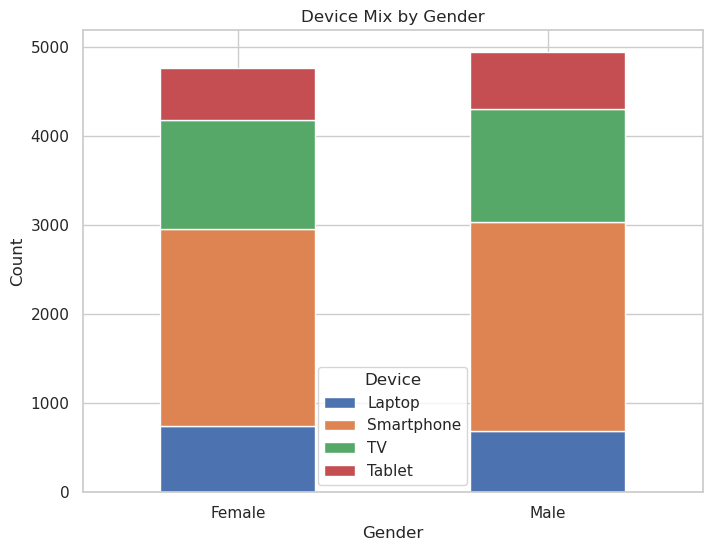

In [22]:
# Stacked bar chart showing device usage composition by gender
pd.crosstab(df['Gender'], df['Primary_Device']).plot(
    kind='bar',
    stacked=True,
    figsize=(8,6)
)

plt.title("Device Mix by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.legend(title="Device")

plt.show()

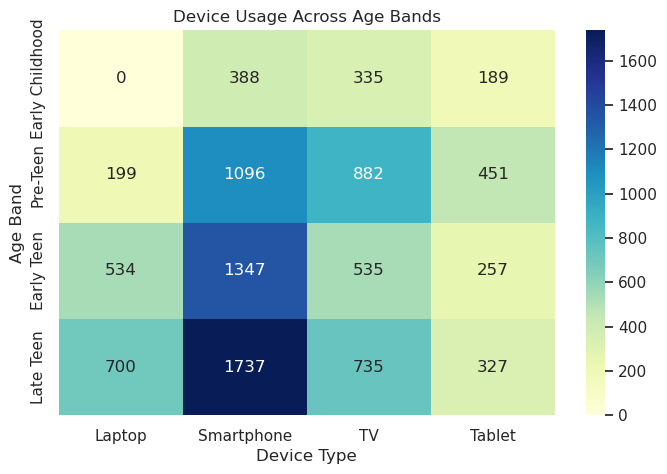

In [23]:
# Heatmap showing device preference across age bands
device_age = pd.crosstab(df['Age_Band'], df['Primary_Device'])

plt.figure(figsize=(8,5))
sns.heatmap(device_age, annot=True, cmap="YlGnBu", fmt='d')

plt.title("Device Usage Across Age Bands")
plt.xlabel("Device Type")
plt.ylabel("Age Band")

plt.show()

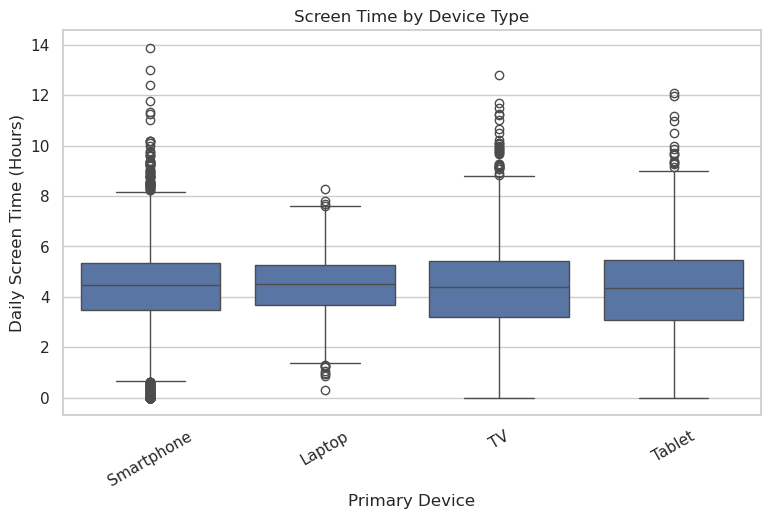

In [24]:
# Boxplot comparing screen time distribution across device types
plt.figure(figsize=(9,5))

sns.boxplot(
    x='Primary_Device',
    y='Avg_Daily_Screen_Time_hr',
    data=df
)

plt.title("Screen Time by Device Type")
plt.xlabel("Primary Device")
plt.ylabel("Daily Screen Time (Hours)")

plt.xticks(rotation=30)

plt.show()

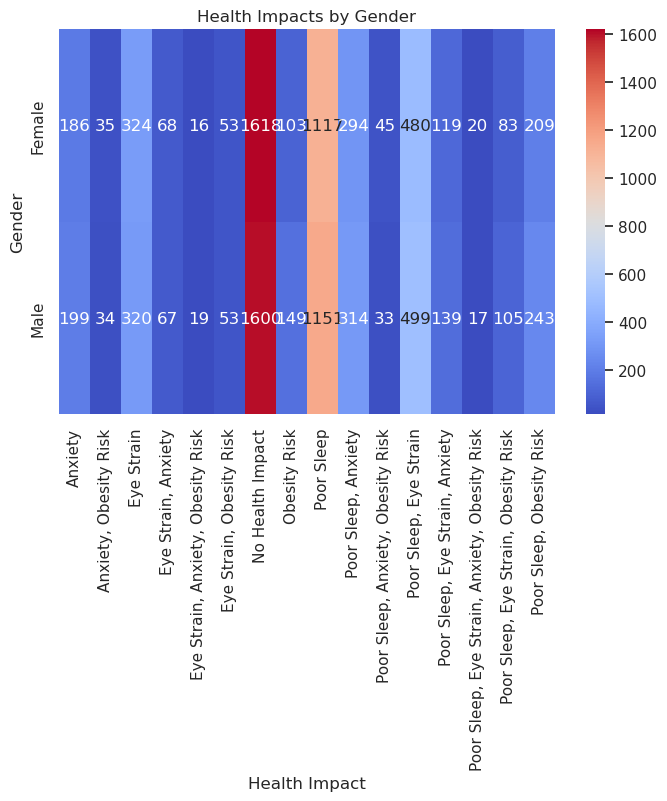

In [25]:
# Heatmap showing distribution of health impacts across gender
impact_gender = pd.crosstab(df['Gender'], df['Health_Impacts'])

plt.figure(figsize=(8,5))
sns.heatmap(impact_gender, annot=True, cmap="coolwarm", fmt='d')

plt.title("Health Impacts by Gender")
plt.xlabel("Health Impact")
plt.ylabel("Gender")

plt.show()

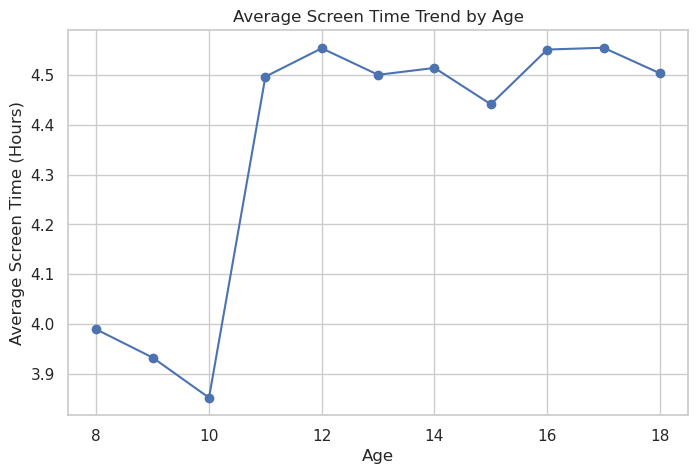

In [26]:
# Line plot showing how screen time changes with age
age_trend = df.groupby("Age")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure(figsize=(8,5))
age_trend.plot(marker='o')

plt.title("Average Screen Time Trend by Age")
plt.xlabel("Age")
plt.ylabel("Average Screen Time (Hours)")

plt.show()

In [27]:

#Weekday/Weekend Analysis

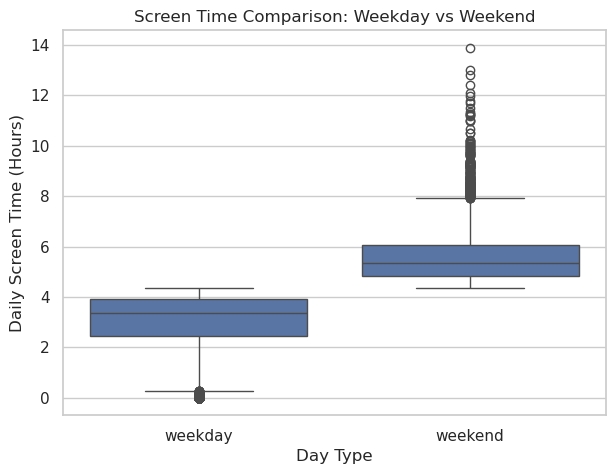

In [28]:
# Boxplot comparing screen time distribution between weekday and weekend
plt.figure(figsize=(7,5))

sns.boxplot(
    x='weekday_flag',
    y='Avg_Daily_Screen_Time_hr',
    data=df
)

plt.title("Screen Time Comparison: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Daily Screen Time (Hours)")

plt.show()

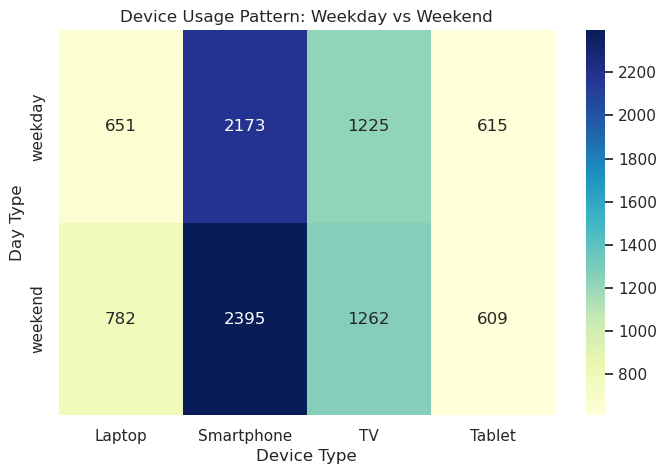

In [29]:
# Heatmap showing device usage intensity for weekday and weekend
device_day = pd.crosstab(df['weekday_flag'], df['Primary_Device'])

plt.figure(figsize=(8,5))
sns.heatmap(device_day, annot=True, cmap="YlGnBu", fmt='d')

plt.title("Device Usage Pattern: Weekday vs Weekend")
plt.xlabel("Device Type")
plt.ylabel("Day Type")

plt.show()

<Figure size 800x500 with 0 Axes>

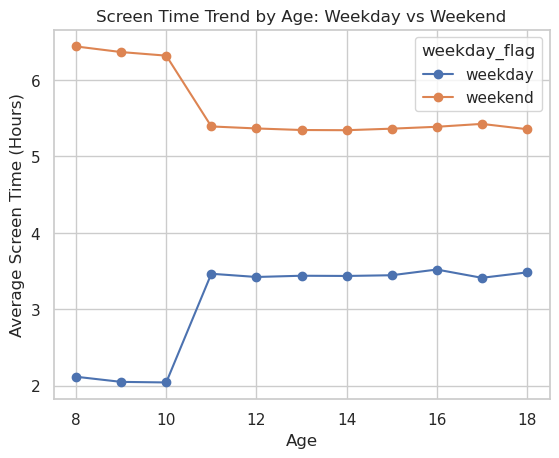

In [30]:
# Line plot comparing screen time trend across ages for weekday and weekend
age_trend = df.groupby(['Age','weekday_flag'])['Avg_Daily_Screen_Time_hr'].mean().unstack()

plt.figure(figsize=(8,5))
age_trend.plot(marker='o')

plt.title("Screen Time Trend by Age: Weekday vs Weekend")
plt.xlabel("Age")
plt.ylabel("Average Screen Time (Hours)")

plt.show()

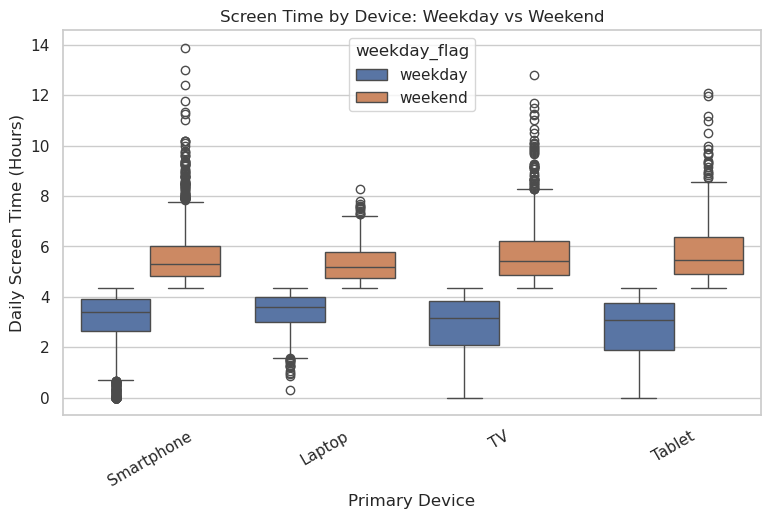

In [31]:
# Boxplot comparing screen time by device for weekday and weekend
plt.figure(figsize=(9,5))

sns.boxplot(
    x='Primary_Device',
    y='Avg_Daily_Screen_Time_hr',
    hue='weekday_flag',
    data=df
)

plt.title("Screen Time by Device: Weekday vs Weekend")
plt.xlabel("Primary Device")
plt.ylabel("Daily Screen Time (Hours)")

plt.xticks(rotation=30)

plt.show()

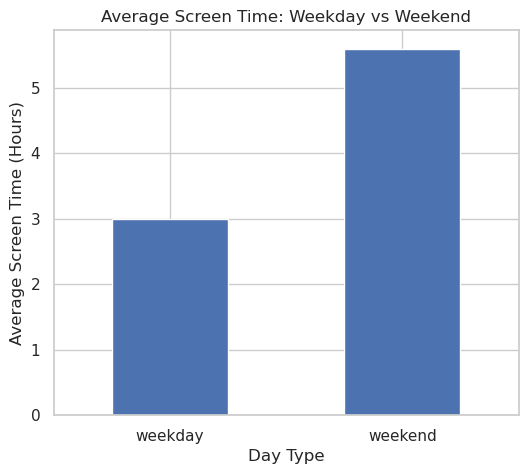

In [32]:
# Bar chart showing average screen time for weekday and weekend
weekday_avg = df.groupby('weekday_flag')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(6,5))
weekday_avg.plot(kind='bar')

plt.title("Average Screen Time: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Screen Time (Hours)")

plt.xticks(rotation=0)

plt.show()

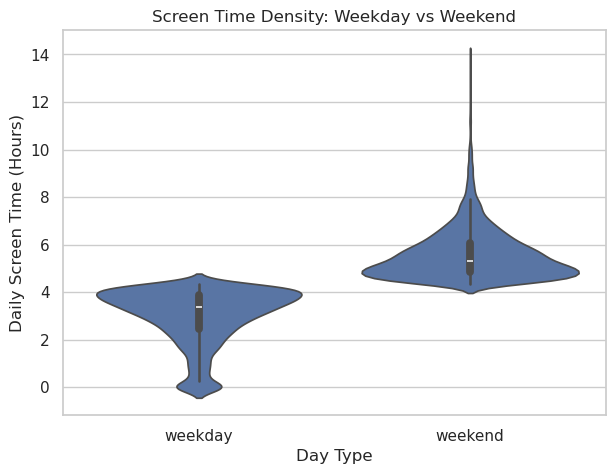

In [33]:
# Violin plot showing density distribution of screen time for weekday and weekend
plt.figure(figsize=(7,5))

sns.violinplot(
    x='weekday_flag',
    y='Avg_Daily_Screen_Time_hr',
    data=df
)

plt.title("Screen Time Density: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Daily Screen Time (Hours)")

plt.show()

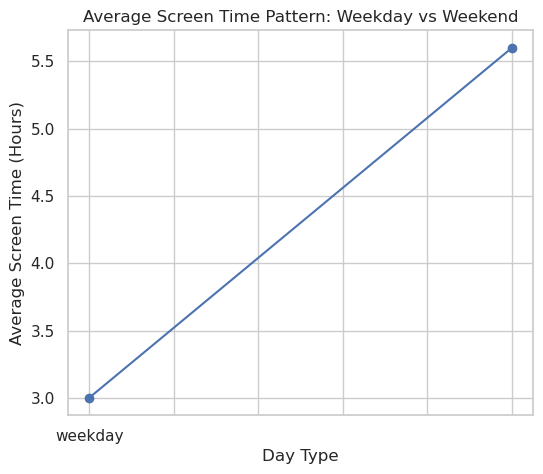

In [34]:
# Line plot comparing average screen time between weekday and weekend
day_avg = df.groupby('weekday_flag')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure(figsize=(6,5))
day_avg.plot(marker='o')

plt.title("Average Screen Time Pattern: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Screen Time (Hours)")

plt.show()

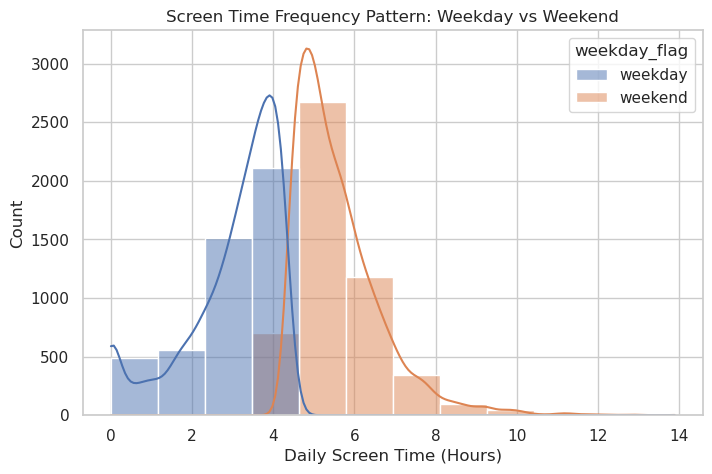

In [35]:
# Histogram showing frequency distribution of screen time for weekday and weekend
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Avg_Daily_Screen_Time_hr',
    hue='weekday_flag',
    bins=12,
    kde=True
)

plt.title("Screen Time Frequency Pattern: Weekday vs Weekend")
plt.xlabel("Daily Screen Time (Hours)")
plt.ylabel("Count")

plt.show()